# The Inverse-Kinematics Inconsistency in ARTIST

**One-slide idea.** ARTIST's kinematic model has two maps, for a fixed sun direction:

| map | call | answers |
|-----|------|---------|
| **forward** | `_compute_orientations_from_motor_positions` | *given these motors, where does the beam point?* |
| **inverse** | `incident_ray_directions_to_orientations` | *to aim there, what motors do I need?* |

These should be **exact opposites**: if the inverse says *"to hit the centre, use motors $m$"*, then the
forward map run on $m$ must put the beam **on the centre**. Going inverse → forward should return you to
where you started.

**This notebook shows that it does not.** We ask the inverse for the motors that aim at the receiver
centre, then feed those exact motors through the forward model and see where the beam actually lands.
It misses the centre, and the miss grows with the heliostat's rotation deviations — which the analytical
inverse silently ignores.

In [1]:
import sys, pathlib, json
import torch, h5py
import numpy as np
import matplotlib.pyplot as plt

# project paths (reuse one_heliostat_demo config for scenario / data locations)
_demo = pathlib.Path.cwd().parent / "one_heliostat_demo" / "single_heliostat"
sys.path.insert(0, str(_demo)); sys.path.insert(0, str(_demo.parent.parent))
import config as cfg
from artist.scenario.scenario import Scenario
from artist.util import get_device, indices

device = get_device()
HID = "AC33"

# Load a single-heliostat scenario.
with h5py.File(cfg.SCENARIO_PATH_TEMPLATE.format(heliostat_id=HID), "r") as fh:
    scenario = Scenario.load_scenario_from_hdf5(
        scenario_file=fh, device=device,
        number_of_surface_points_per_facet=torch.tensor([25, 25]))
hg  = scenario.heliostat_field.heliostat_groups[0]
kin = hg.kinematics

# One realistic sun direction + the receiver centre it aimed at (from a calibration sample).
cal = json.load(open(sorted((pathlib.Path(cfg.SYNTHETIC_DATASET_DIR)/"train"/HID)
                            .glob("*/calibration_properties.json"))[0]))
sun        = torch.tensor([cal["incident_ray_direction"]], dtype=torch.float32, device=device)
target_idx = torch.tensor([cal["target_area_index"]], device=device)
centre     = scenario.solar_tower.get_centers_of_target_areas(target_idx, device=device)
print(f"Heliostat {HID}  |  sun direction {sun[0,:3].cpu().numpy().round(3)}")

Setting device to CPU. ARTIST only supports CPU for MacOS.


Heliostat AC33  |  sun direction [-0.503  0.422 -0.754]


## The round-trip test

1. **Inverse:** `aim = centre` → motor positions `m_inv` (this is exactly what `align_surfaces_*` does).
2. **Forward:** run `m_inv` back through `_compute_orientations_from_motor_positions` to get the mirror
   normal, reflect the sun off it, and intersect the receiver plane → **where the beam actually lands**.
3. Compare that landing point to the centre we asked for.

We run it twice: an **ideal** heliostat (no deviations) and one with **realistic rotation deviations**.

In [2]:
NORMAL = torch.tensor([0., -1., 0., 0.], device=device)  # ARTIST concentrator normal in homogeneous frame

def round_trip(rotation_deviation, n_iter=2):
    """Aim at the centre via the inverse, forward-trace the motors, return where the beam lands."""
    mask = torch.tensor([1], device=device)
    hg.activate_heliostats(active_heliostats_mask=mask, device=device)
    kin.rotation_deviation_parameters.data[:] = torch.tensor([rotation_deviation], device=device)
    hg.activate_heliostats(active_heliostats_mask=mask, device=device)  # propagate to active params

    # (1) INVERSE: motors to aim at the centre
    kin.incident_ray_directions_to_orientations(
        incident_ray_directions=sun, aim_points=centre, device=device, max_num_iterations=n_iter)
    m_inv = kin.active_motor_positions.detach().clone()

    # (2) FORWARD: where do those motors actually point?
    orientation = kin._compute_orientations_from_motor_positions(m_inv, device)
    normal_fwd  = torch.nn.functional.normalize((orientation @ NORMAL)[:, :3], dim=-1)

    # reflect the sun off the forward normal and intersect the receiver plane
    origin   = kin.active_heliostat_positions[:, :3]
    incident = torch.nn.functional.normalize(sun[:, :3], dim=-1)
    reflect  = incident - 2 * (incident * normal_fwd).sum(-1, keepdim=True) * normal_fwd
    planar   = scenario.solar_tower.target_areas[indices.planar_target_areas]
    plane_n  = torch.nn.functional.normalize(planar.normals[target_idx][:, :3], dim=-1)
    ctr3     = centre[:, :3]
    t        = ((ctr3 - origin) * plane_n).sum(-1) / (reflect * plane_n).sum(-1)
    hit      = origin + t[:, None] * reflect

    miss_m    = torch.norm(hit - ctr3, dim=1).item()
    hel_dist  = torch.norm(origin - ctr3, dim=1).item()
    # 2-D offset in the receiver plane (east, up), centre at origin
    off_east  = (hit[0, 0] - ctr3[0, 0]).item()
    off_up    = (hit[0, 2] - ctr3[0, 2]).item()
    return dict(m_inv=m_inv[0].cpu().numpy(), miss_m=miss_m, miss_mrad=miss_m/hel_dist*1000,
                off_east=off_east, off_up=off_up, hel_dist=hel_dist)

ideal = round_trip([0.0, 0.0, 0.0, 0.0])
real  = round_trip([0.004, 0.003, -0.004, 0.001])   # ~4 mrad tilts, realistic scale

print(f"distance heliostat -> receiver: {ideal['hel_dist']:.0f} m\n")
print("IDEAL heliostat (no deviations):")
print(f"   inverse motors      = {ideal['m_inv'].round(1)}")
print(f"   beam misses centre by {ideal['miss_m']*100:5.1f} cm  ({ideal['miss_mrad']:.2f} mrad)\n")
print("REALISTIC rotation deviations [4, 3, -4, 1] mrad:")
print(f"   inverse motors      = {real['m_inv'].round(1)}   (nearly identical to ideal!)")
print(f"   beam misses centre by {real['miss_m']*100:5.1f} cm  ({real['miss_mrad']:.2f} mrad)")

distance heliostat -> receiver: 62 m

IDEAL heliostat (no deviations):
   inverse motors      = [27032. 38565.]
   beam misses centre by  17.3 cm  (2.78 mrad)

REALISTIC rotation deviations [4, 3, -4, 1] mrad:
   inverse motors      = [27031.5 38565.1]   (nearly identical to ideal!)
   beam misses centre by 115.5 cm  (18.48 mrad)


## Picture: where the inverse *says* to aim vs where the beam *actually* lands

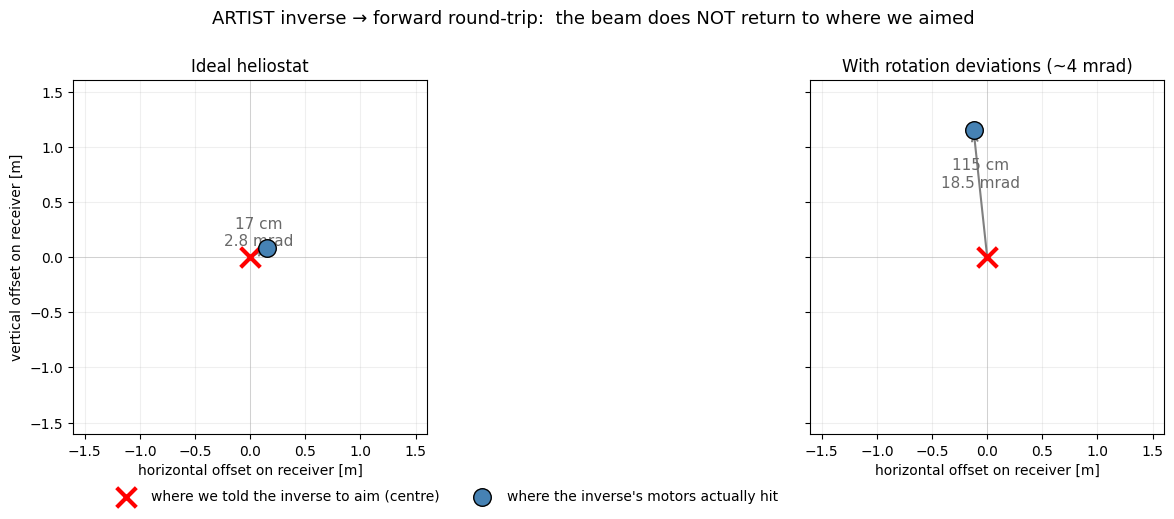

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)
for ax, res, title in [(axes[0], ideal, "Ideal heliostat"),
                       (axes[1], real,  "With rotation deviations (~4 mrad)")]:
    # aim point (centre) at origin
    ax.scatter([0], [0], marker="x", s=200, c="red", linewidths=3,
               label="where we told the inverse to aim (centre)", zorder=5)
    # actual beam landing
    ax.scatter([res["off_east"]], [res["off_up"]], s=160, c="steelblue",
               edgecolors="black", label="where the inverse's motors actually hit", zorder=6)
    ax.annotate("", xy=(res["off_east"], res["off_up"]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
    ax.text(res["off_east"]/2, res["off_up"]/2 + 0.06,
            f"{res['miss_m']*100:.0f} cm\n{res['miss_mrad']:.1f} mrad",
            fontsize=11, ha="center", color="dimgray")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("horizontal offset on receiver [m]")
    ax.axhline(0, color="0.85", lw=0.7, zorder=0); ax.axvline(0, color="0.85", lw=0.7, zorder=0)
    ax.set_aspect("equal"); ax.grid(alpha=0.2)
axes[0].set_ylabel("vertical offset on receiver [m]")
axes[0].legend(loc="upper center", bbox_to_anchor=(1.05, -0.12), ncol=2, fontsize=10, frameon=False)
lim = max(0.3, abs(real["off_east"]), abs(real["off_up"])) * 1.4
axes[0].set_xlim(-lim, lim); axes[0].set_ylim(-lim, lim)
fig.suptitle("ARTIST inverse → forward round-trip:  the beam does NOT return to where we aimed",
             fontsize=13, y=1.0)
plt.tight_layout(); plt.show()

## It is not a convergence issue — more inverse iterations don't help

The inverse is an iterative analytical solver. If the miss were just under-convergence, running it longer
would shrink it. It doesn't: the error is **structural** — the analytical solution simply never accounts
for the rotation-deviation parameters.

In [4]:
print("rotation deviations [4, 3, -4, 1] mrad:")
for it in [2, 5, 20, 80]:
    r = round_trip([0.004, 0.003, -0.004, 0.001], n_iter=it)
    print(f"  {it:2d} inverse iterations  ->  beam misses centre by {r['miss_mrad']:.3f} mrad")

rotation deviations [4, 3, -4, 1] mrad:
   2 inverse iterations  ->  beam misses centre by 18.481 mrad
   5 inverse iterations  ->  beam misses centre by 18.481 mrad
  20 inverse iterations  ->  beam misses centre by 18.481 mrad
  80 inverse iterations  ->  beam misses centre by 18.481 mrad


## Takeaway

* The inverse computes motor positions to *aim at the centre*, but feeding those exact motors through the
  forward model lands the beam **~18 mrad (over 1 m at 60 m) off centre**.
* The miss **grows with the rotation deviations** (ideal ≈ 3 mrad → realistic ≈ 18 mrad) and is
  **independent of the number of solver iterations** — so it is a structural inconsistency, not numerical
  noise. ARTIST's analytical inverse `incident_ray_directions_to_orientations` solves the joint angles
  using only the *translation* deviations and **never inverts the rotation deviations** that the forward
  model applies.
* **Consequence for calibration:** any loss that compares motor positions through this inverse
  (‖ inverse(centre or c_gt) − recorded motors ‖) is comparing inconsistent quantities, so its minimum is
  not at the true parameters. The fix is to use only the **forward** map: match the forward normal at the
  recorded motors against the geometric desired normal, never round-tripping through the inverse.